# Case 03 — Demand Forecasting Under Uncertainty
### PROVIDENTIA Evidence Pack — forecasting notebook

This notebook reads **only files inside this same folder**
(`forecasting_metrics.csv`, `development_vs_final.csv`, `figures/`). It does
not import `src/providentia`, and does not read `data/raw/` or
`data/processed/` from the source repository. No model is trained or
retrained here — every number plotted below is an already-frozen metric
copied from PROVIDENTIA's `reports/` artifacts (see `portfolio_manifest.json`
for exact source files and hashes).

Sections: profiling summary → model comparison (baselines, ETS, SARIMA,
LightGBM) → development vs final generalization gap → interval calibration →
conclusions & limitations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

HERE = Path.cwd()
metrics = pd.read_csv(HERE / "forecasting_metrics.csv")
gaps = pd.read_csv(HERE / "development_vs_final.csv")

print("forecasting_metrics.csv:", metrics.shape)
print("development_vs_final.csv:", gaps.shape)
metrics.head()

forecasting_metrics.csv: (88, 10)
development_vs_final.csv: (44, 8)


,evaluation_set,model_id,role,metric_family,metric_id,level,value,support_n,series_n,aggregation
0,DEVELOPMENT,naive,baseline,point,mae,NaN,69.712733,6534,198,micro
1,DEVELOPMENT,naive,baseline,point,rmse,NaN,116.966338,6534,198,micro
2,DEVELOPMENT,naive,baseline,point,wape,NaN,0.117931,6534,198,micro
3,DEVELOPMENT,naive,baseline,point,mase,NaN,1.068885,6534,198,micro
4,DEVELOPMENT,seasonal_naive,baseline,point,mae,NaN,83.851393,6534,198,micro


## 1. Profiling summary (P1)

Profiling in PROVIDENTIA is purely descriptive (no forecasts, no baselines,
no training were run in P1). The numbers below are quoted, not recomputed,
from the frozen `reports/p1/etsa-report.md` narrative, because reproducing
them requires the raw StatsWales snapshot, which this pack intentionally
does not include (see `data_attribution.md`).

| Metric | Value |
|---|---|
| Rows in analysis table | 30,747 |
| Series (board × specialty) | 214 |
| Provider health boards | 7 |
| Specialties | 50 |
| Date range | 2012-04 to 2026-06 (171 months) |
| Series with complete balanced history | 129 |
| Series partial / with gaps | 85 |
| Mean / median referrals per observation | 506.8 / 251.0 |
| Skewness | 1.92 (right-skewed) |
| Trend mix (series-level) | 103 approximately stable · 96 increasing · 15 decreasing |
| Largest structural break | COVID-19 (2020-03 to 2021-06); median post/pre ratio ≈ 1.18 |

A representative-series figure, reused unmodified from
`reports/p1/figures/06-representative-series.png`:

![Representative series](figures/p1-06-representative-series.png)

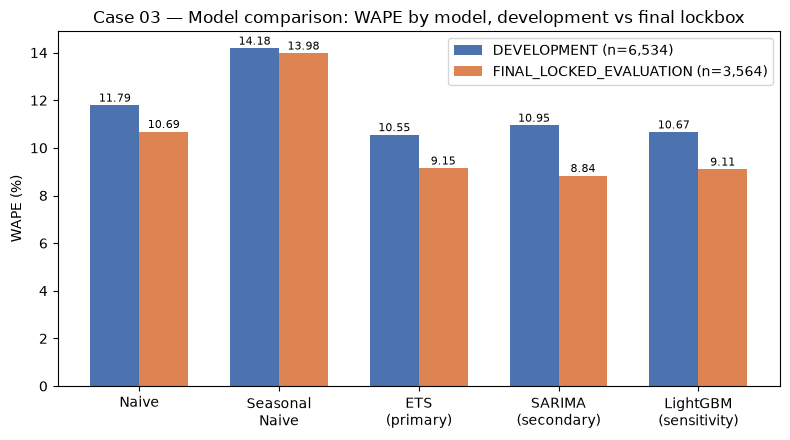

Final lockbox WAPE ranking (ascending):
model_id
sarima_aicc                 8.84
lightgbm_global_full_v1     9.11
ets_aicc                    9.15
naive                      10.69
seasonal_naive             13.98
Name: value, dtype: float64


In [2]:
# --- Chart 1: model comparison — WAPE, DEVELOPMENT vs FINAL_LOCKED_EVALUATION ---
model_order = ["naive", "seasonal_naive", "ets_aicc", "sarima_aicc", "lightgbm_global_full_v1"]
labels = ["Naive", "Seasonal\nNaive", "ETS\n(primary)", "SARIMA\n(secondary)", "LightGBM\n(sensitivity)"]

wape = metrics[(metrics.metric_family == "point") & (metrics.metric_id == "wape")]
dev_wape = wape[wape.evaluation_set == "DEVELOPMENT"].set_index("model_id").loc[model_order, "value"]
final_wape = wape[wape.evaluation_set == "FINAL_LOCKED_EVALUATION"].set_index("model_id").loc[model_order, "value"]

fig, ax = plt.subplots(figsize=(8, 4.5))
x = range(len(model_order))
w = 0.35
ax.bar([i - w/2 for i in x], dev_wape.values * 100, width=w, label="DEVELOPMENT (n=6,534)", color="#4C72B0")
ax.bar([i + w/2 for i in x], final_wape.values * 100, width=w, label="FINAL_LOCKED_EVALUATION (n=3,564)", color="#DD8452")
ax.set_xticks(list(x)); ax.set_xticklabels(labels)
ax.set_ylabel("WAPE (%)")
ax.set_title("Case 03 — Model comparison: WAPE by model, development vs final lockbox")
ax.legend()
for i, (d, f) in enumerate(zip(dev_wape.values, final_wape.values)):
    ax.text(i - w/2, d*100 + 0.15, f"{d*100:.2f}", ha="center", fontsize=8)
    ax.text(i + w/2, f*100 + 0.15, f"{f*100:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

print("Final lockbox WAPE ranking (ascending):")
print((final_wape * 100).round(2).sort_values())

**Note on the final ranking.** On the final lockbox, `sarima_aicc` scores a
small margin better than `ets_aicc` on WAPE/MAE/RMSE (8.84% vs 9.15% WAPE
above). This is a **descriptive ranking on one reserved period only**. Per
`DDR-007`, the primary model (`ets_aicc`) was fixed *before* the lockbox was
opened, and `post_lockbox_selection`/`post_lockbox_tuning` are `false` in
`config/p7_final.yaml` — **this result did not trigger retuning or model
switching.** The frozen primary model and reference decision policy remain
`ets_aicc` × `PI90`. Both baselines (Naive, Seasonal Naive) remain visible
above and are clearly beaten by all three candidate models, on both
evaluation sets — LightGBM was never guaranteed to win, and did not need to
for the MVP to be considered scientifically valid.

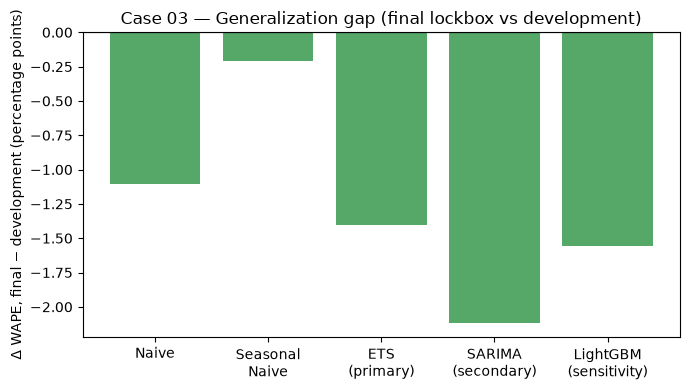

All policy_changed flags (must all be False): [False, False, False, False, False]


,development,final,gap_final_minus_development,policy_changed
model_id,,,,
naive,0.117931,0.106855,-0.011077,False
seasonal_naive,0.141849,0.139770,-0.002080,False
ets_aicc,0.105527,0.091521,-0.014006,False
sarima_aicc,0.109494,0.088351,-0.021143,False
lightgbm_global_full_v1,0.106661,0.091062,-0.015600,False


In [3]:
# --- Chart 2: development -> final generalization gap (WAPE) ---
gap_wape = gaps[(gaps.metric_family == "point") & (gaps.metric_id == "wape")].set_index("model_id").loc[model_order]

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#55A868" if v < 0 else "#C44E52" for v in gap_wape["gap_final_minus_development"]]
ax.bar(labels, gap_wape["gap_final_minus_development"] * 100, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Δ WAPE, final − development (percentage points)")
ax.set_title("Case 03 — Generalization gap (final lockbox vs development)")
plt.tight_layout()
plt.show()

print("All policy_changed flags (must all be False):", gap_wape["policy_changed"].tolist())
gap_wape[["development", "final", "gap_final_minus_development", "policy_changed"]]

WAPE improved (negative gap, green) on the final lockbox relative to
development for all three candidate models; the two baselines shifted only
mildly. `policy_changed` is `False` for every model — the gap is reported,
not reacted to. This matches PROVIDENTIA's own conclusion: *"small and
mixed-sign, consistent with normal period-to-period variation, not with a
regression."*

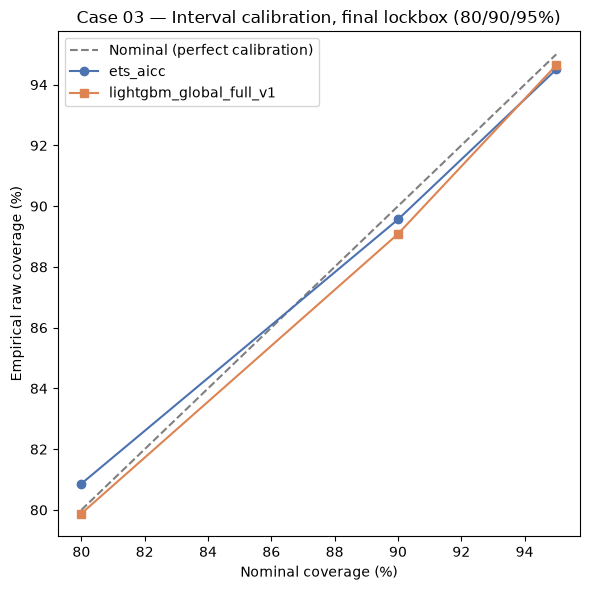

model_id,ets_aicc,lightgbm_global_full_v1
level,,
0.80,80.86,79.88
0.90,89.56,89.09
0.95,94.50,94.64


In [4]:
# --- Chart 3: prediction interval calibration (final lockbox, both models) ---
interval_cov = metrics[
    (metrics.metric_family == "interval")
    & (metrics.metric_id == "coverage")
    & (metrics.evaluation_set == "FINAL_LOCKED_EVALUATION")
].copy()
interval_cov["level"] = interval_cov["level"].astype(float)

fig, ax = plt.subplots(figsize=(6, 6))
levels = sorted(interval_cov["level"].unique())
ax.plot([l*100 for l in levels], [l*100 for l in levels], "--", color="gray", label="Nominal (perfect calibration)")
for model, marker, color in [("ets_aicc", "o", "#4C72B0"), ("lightgbm_global_full_v1", "s", "#DD8452")]:
    sub = interval_cov[interval_cov.model_id == model].sort_values("level")
    ax.plot(sub["level"] * 100, sub["value"] * 100, marker=marker, color=color, label=model)
ax.set_xlabel("Nominal coverage (%)")
ax.set_ylabel("Empirical raw coverage (%)")
ax.set_title("Case 03 — Interval calibration, final lockbox (80/90/95%)")
ax.legend()
plt.tight_layout()
plt.show()

interval_cov.pivot(index="level", columns="model_id", values="value").round(4) * 100

All six points (2 models × 3 levels) sit within about one percentage point
of the diagonal — no level or model shows gross miscalibration on the final
lockbox. These prediction intervals are exactly the input Case 04 (Capacity
Decision Intelligence) turns into a required-capacity policy — that
translation itself is out of scope for this pack.

In [5]:
# --- Self-check: exported values match the headline numbers documented in README.md ---
expected = {
    ("ets_aicc", "DEVELOPMENT"): 0.1055272666861122,
    ("ets_aicc", "FINAL_LOCKED_EVALUATION"): 0.0915211380161353,
    ("sarima_aicc", "FINAL_LOCKED_EVALUATION"): 0.0883505486690591,
}
for (model, ev), exp in expected.items():
    got = wape[(wape.model_id == model) & (wape.evaluation_set == ev)]["value"].iloc[0]
    assert abs(got - exp) < 1e-12, (model, ev, got, exp)
print("Self-check OK: forecasting_metrics.csv values match the documented headline numbers.")

Self-check OK: forecasting_metrics.csv values match the documented headline numbers.


## Conclusions

- All three candidate models (ETS, SARIMA, LightGBM) beat both mandatory
  baselines (Naive, Seasonal Naive) on WAPE, on development **and** on the
  final lockbox.
- The frozen primary model is `ets_aicc` (fixed by `DDR-007` before the
  lockbox opened). On the final lockbox, `sarima_aicc` scored a small margin
  better — this is reported transparently and did **not** change the frozen
  model or policy, per the project's no-retuning / no-post-lockbox-selection
  rule.
- The generalization gap (development → final) is small and mixed-sign for
  point accuracy, and interval calibration stays within ~1 point of nominal
  at every level on the final lockbox.
- The final lockbox (`B198_FINAL_LOCKBOX_V1`) was opened **exactly once**,
  under recorded human authorization, and is now `SCORED` — it cannot return
  to `SEALED`. This notebook reports that single evaluation; it does not,
  and cannot, re-run it.

## Limitations (preserve exactly when reusing this pack)

- **Not staffing, not appointments, not hospital capacity.** The target is
  observed referral demand upstream of appointments; PROVIDENTIA does not
  claim actual hospital capacity, actual saturation, staff shortage, unmet
  patient demand, a guaranteed future service level, optimal capacity, or
  monetary savings (`config/p7_claims.yaml`).
- **Not generalizable beyond Welsh NHS referral activity.** Results describe
  this dataset and system only.
- Monthly granularity cannot support daily staffing or within-month peaks.
- Demand censoring (referrals are upstream of appointments but still not a
  direct measure of potential demand) is a documented, unresolved
  limitation (`DDR-001`).
- Welsh health-board boundaries changed in April 2019; COVID-19 is a major,
  documented structural break in the series.
- This pack contains no raw or processed row-level data — see
  `data_attribution.md` for how to obtain the source dataset and the licence
  that governs it (StatsWales, Open Government Licence v3.0).